## **Pipeline de Limpeza e Pré-Processamento de Dados**

##### Tony Esaú de Oliveira - Universidade Federal do Cariri

No sentido de processo geral, um *pipeline* é basicamente um fluxo de trabalho estruturado - uma série de etapas ordenadas que transformam algo desde o início até o resultado final. A ideia é que você pega uma entrada (matéria-prima, informação, tarefa), passa por diferentes estágios de processamento ou transformação, e no final obtém o resultado desejado. Cada etapa tem sua função específica e depende da anterior. Características principais:

* **Sequencial:** as etapas seguem uma ordem lógica;
* **Conectado:** a saída de uma fase alimenta a próxima;
* **Transformador:** cada etapa agrega valor ou modifica o item;
* **Repetível:** o mesmo processo pode ser aplicado a múltiplos itens.

---

#### **Objetivos**
O objetivo desse *Notebook* é fazer uma *pipeline* de Limpeza e Pré-Processamento de Dados. Dando ênfase as etapas principais e básicas até o resultado final, que é um conjunto de dados mais preciso e mais enriquecedor para uma análise mais profunda e acertada. É importante sempre se lembrar que *Garbage in, garbage out*. 

---

### **1. Estudo do Conjunto de Dados**

Inicialmente, é necessário saber do que se trata o Conjunto de Dados que será analisado e quais suas características. Essa parte inicial é atrelada ao contexto dos dados e seus profissionais, então se informar com esses e entender o que é importante ou não é extremamente essencial. Caso isso seja impossível, é imprescindível que se faça um estudo próprio com uma descrição estruturada e detalhada que facilite o restante do *pipeline* de Limpeza e Pré-processamento.

##### **1.1 Conjunto de Dados**

O conjunto de dados que usaremos nesse *Notebook* é o **Dirty_Dataset**, um conjunto de Dados didáticos pequeno criado para a prática de limpeza de dados. Na aba *sobre* diz que *The dataset has been obtained by web scraping a Wikipedia page for which code is linked below: https://www.kaggle.com/amruthayenikonda/simple-web-scraping-using-pandas*.

##### **1.2 Descrevendo Colunas**

Essa decrição inicial deve ser minuciosa e, de preferência, manual. Caso seja impossível fazer manualmente (muitas colunas), faça com o auxílio de ferramentas de exploração como o *pandas*.

**Dataset de Turnês Musicais:** este dataset contém informações sobre as maiores turnês musicais de maior arrecadação de todos os tempos feita por mulheres, com dados sobre artistas, valores brutos e ajustados, datas e estatísticas de shows.

| Coluna | Tipo | Descrição | Exemplo |
|--------|------|-----------|---------|
| **Rank** | Numérico | Posição da turnê no ranking atual de maiores arrecadações | 1, 2, 3 |
| **Peak** | Numérico | Melhor posição que a turnê já alcançou no ranking histórico | 1, 2 |
| **All Time Peak** | Numérico | Pico histórico absoluto considerando todas as turnês já realizadas | 2, 7, 10 |
| **Actual gross** | Monetário (string) | Valor bruto arrecadado pela turnê em dólares nominais (não ajustados pela inflação) | "$780,000,000" |
| **Adjusted gross (in 2022 dollars)** | Monetário (string) | Valor bruto arrecadado ajustado pela inflação para dólares de 2022, permitindo comparação justa entre diferentes épocas | "$780,000,000" |
| **Artist** | Texto | Nome do artista ou banda que realizou a turnê | "Taylor Swift", "Beyoncé" |
| **Tour title** | Texto | Nome oficial da turnê. Símbolos especiais indicam: † = turnê em andamento, ‡ = turnê com múltiplas pernas/etapas | "The Eras Tour †" |
| **Year(s)** | Texto | Período em que a turnê ocorreu, podendo abranger um ou mais anos | "2023–2024", "2008–2009" |
| **Shows** | Numérico | Número total de shows/apresentações realizadas durante a turnê | 56, 85, 131 |
| **Average gross** | Monetário (string) | Arrecadação média por show (Actual gross ÷ Shows) | "$13,928,571" |
| **Ref.** | Texto | Referências bibliográficas ou notas de rodapé sobre a fonte dos dados | "[1]", "[3]" |

##### **Símbolos Especiais**
- **†** (cruz): Turnê ainda em andamento;
- **‡** (cruz dupla): Turnê com múltiplas pernas/etapas em diferentes períodos;
- **\*** (asterisco): Informação desconhecida.



### **2. Inspeção e Diagnóstico Inicial**

In [152]:
# Algumas importações básicas.
import pandas as pd
import numpy as np

##### **2.1 Carregamento e Primeira Inspeção**

In [200]:
# Outras possíveis leituras de dados: pd.read_excel(), pd.read_parquet().
dados = pd.read_csv('Dirty_Dataset.csv') 

In [154]:
# Tipos de dados, memória, valores não-nulos.
dados.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Rank                              20 non-null     int64 
 1   Peak                              9 non-null      object
 2   All Time Peak                     6 non-null      object
 3   Actual gross                      20 non-null     object
 4   Adjusted gross (in 2022 dollars)  20 non-null     object
 5   Artist                            20 non-null     object
 6   Tour title                        20 non-null     object
 7   Year(s)                           20 non-null     object
 8   Shows                             20 non-null     int64 
 9   Average gross                     20 non-null     object
 10  Ref.                              20 non-null     object
dtypes: int64(2), object(9)
memory usage: 1.8+ KB


In [155]:
# Estatísticas descritivas para valores numéricos.
dados.describe()

,Rank,Shows
count,20.000000,20.000000
mean,10.450000,110.000000
std,5.942488,66.507617
min,1.000000,41.000000
25%,5.750000,59.000000
50%,10.500000,87.000000
75%,15.250000,134.500000
max,20.000000,325.000000


In [156]:
# Cabeçalho dos dados.
dados.head()

,Rank,Peak,All Time Peak,Actual gross,Adjusted gross (in 2022 dollars),Artist,Tour title,Year(s),Shows,Average gross,Ref.
0,1,1,2,"$780,000,000","$780,000,000",Taylor Swift,The Eras Tour †,2023–2024,56,"$13,928,571",[1]
1,2,1,7[2],"$579,800,000","$579,800,000",Beyoncé,Renaissance World Tour,2023,56,"$10,353,571",[3]
2,3,1[4],2[5],"$411,000,000","$560,622,615",Madonna,Sticky & Sweet Tour ‡[4][a],2008–2009,85,"$4,835,294",[6]
3,4,2[7],10[7],"$397,300,000","$454,751,555",Pink,Beautiful Trauma World Tour,2018–2019,156,"$2,546,795",[7]
4,5,2[4],NaN,"$345,675,146","$402,844,849",Taylor Swift,Reputation Stadium Tour,2018,53,"$6,522,173",[8]


In [157]:
# Cauda dos dados.
dados.tail()

,Rank,Peak,All Time Peak,Actual gross,Adjusted gross (in 2022 dollars),Artist,Tour title,Year(s),Shows,Average gross,Ref.
15,16,NaN,NaN,"$184,000,000","$227,452,347",Pink,The Truth About Love Tour,2013–2014,142,"$1,295,775",[22]
16,17,NaN,NaN,"$170,000,000","$213,568,571",Lady Gaga,Born This Way Ball,2012–2013,98,"$1,734,694",[d]
17,18,NaN,NaN,"$169,800,000","$207,046,755",Madonna,Rebel Heart Tour,2015–2016,82,"$2,070,732",[4]
18,19,NaN,NaN,"$167,700,000[e]","$204,486,106",Adele,Adele Live 2016,2016–2017,121,"$1,385,950",[25]
19,20,NaN,NaN,"$150,000,000","$185,423,109",Taylor Swift,The Red Tour,2013–2014,86,"$1,744,186",[26]


In [158]:
# Amostra aleatória dos dados.
dados.sample()

,Rank,Peak,All Time Peak,Actual gross,Adjusted gross (in 2022 dollars),Artist,Tour title,Year(s),Shows,Average gross,Ref.
14,15,2[c],NaN,"$194,000,000","$281,617,035",Madonna,Confessions Tour,2006,60,"$3,233,333",[5]


In [110]:
# Dimensões do dataset.
print('Dimensões:', dados.shape,'\n')

# Armazenando lista de colunas.
lista_dados = dados.columns.tolist()
print('Lista de colunas:', lista_dados, '\n')

# Tipos de dados de cada coluna.
print('Tipos de dados: \n')
print(dados.dtypes)

# Armazenando tipos de dados em uma lista para ação futura.
tipos_dados = dados.dtypes.to_list() #

Dimensões: (20, 11) 

Lista de colunas: ['Rank', 'Peak', 'All Time Peak', 'Actual\xa0gross', 'Adjusted\xa0gross (in 2022 dollars)', 'Artist', 'Tour title', 'Year(s)', 'Shows', 'Average gross', 'Ref.'] 

Tipos de dados: 

Rank                                 int64
Peak                                object
All Time Peak                       object
Actual gross                        object
Adjusted gross (in 2022 dollars)    object
Artist                              object
Tour title                          object
Year(s)                             object
Shows                                int64
Average gross                       object
Ref.                                object
dtype: object


Uma das primeiras coisas que podemos notar é a falta de padronização dos nomes da colunas, resolveremos isso mais adiante.

##### **2.2 Análise de Valores Ausentes**

In [159]:
# Contagem de nulos por coluna (.isnull() retorna um objeto de mesmo tamanho do DataFrame original 
# e .sum() soma os valores True de cada coluna, em que True significa valor nulo). 
dados.isnull().sum()

Rank                                 0
Peak                                11
All Time Peak                       14
Actual gross                         0
Adjusted gross (in 2022 dollars)     0
Artist                               0
Tour title                           0
Year(s)                              0
Shows                                0
Average gross                        0
Ref.                                 0
dtype: int64

Ou seja, apenas as colunas `Peak` e `All Time Peak` têm valores nulos (NaN). Isso também poderia ser visto da seguinte forma:

In [160]:
# Colunas com pelo menos um nulo.
dados.isnull().any()

Rank                                False
Peak                                 True
All Time Peak                        True
Actual gross                        False
Adjusted gross (in 2022 dollars)    False
Artist                              False
Tour title                          False
Year(s)                             False
Shows                               False
Average gross                       False
Ref.                                False
dtype: bool

In [161]:
 # Percentual de nulos por coluna.
dados.isnull().sum() / len(dados) * 100

Rank                                 0.0
Peak                                55.0
All Time Peak                       70.0
Actual gross                         0.0
Adjusted gross (in 2022 dollars)     0.0
Artist                               0.0
Tour title                           0.0
Year(s)                              0.0
Shows                                0.0
Average gross                        0.0
Ref.                                 0.0
dtype: float64

Podemos perceber que `All Time Peak` pode ser uma coluna problemática devido o alto percentual de valores nulos. 

In [162]:
# Percentual de nulos em relação ao total de dados.
tamanho = dados.shape[0] * dados.shape[1]

# Soma o total de todas as colunas.
nulos = dados.isnull().sum().sum() 

print(f'Percentual de valores nulos no dataset: {nulos / tamanho * 100:.2f}%')

Percentual de valores nulos no dataset: 11.36%


O percentual de valores nulos é pequeno tendo em vista a totalidade dos dados, isso é um bom indício.

<Axes: >

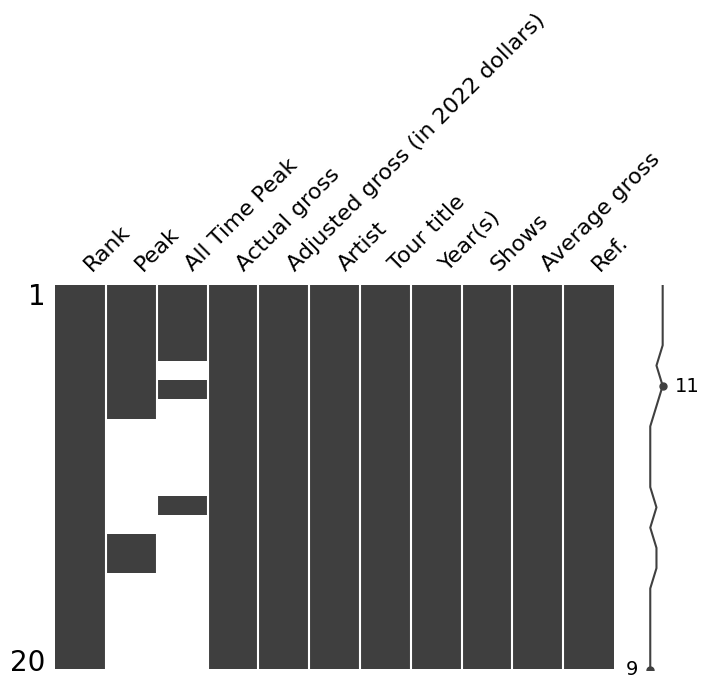

In [163]:
# Biblioteca para visualização de dados faltantes.
import missingno as msno

msno.matrix(dados, figsize=(8, 5))


<Axes: >

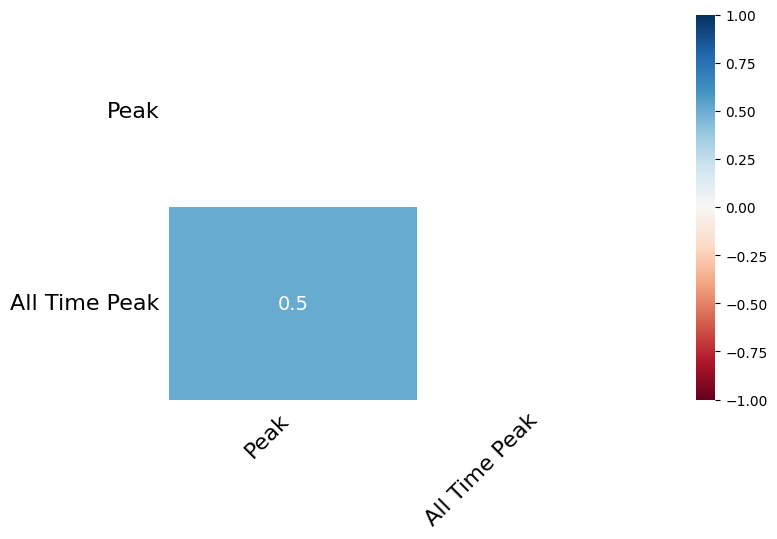

In [164]:
# Correlação de valores ausentes.
msno.heatmap(dados, figsize=(8, 5))

##### **2.3 Análise e Remoção de Duplicatas**

In [165]:
# Total de linhas duplicadas.
duplicados = dados.duplicated().sum()
print(f'Total de linhas duplicadas é: {duplicados}.')

Total de linhas duplicadas é: 0.


O conjunto de dados não tem duplicatas, o que é uma boa notícia.

In [166]:
# Duplicatas por subconjunto.
dados.duplicated(subset=['Rank', 'Actual\xa0gross']).sum() 

np.int64(0)

In [167]:
# Visualizar todas as duplicatas.
print(dados[dados.duplicated(keep=False)])

Empty DataFrame
Columns: [Rank, Peak, All Time Peak, Actual gross, Adjusted gross (in 2022 dollars), Artist, Tour title, Year(s), Shows, Average gross, Ref.]
Index: []


In [168]:
# Remover as linhas duplicadas do DataFrame original.
dados.drop_duplicates() 

,Rank,Peak,All Time Peak,Actual gross,Adjusted gross (in 2022 dollars),Artist,Tour title,Year(s),Shows,Average gross,Ref.
0,1,1,2,"$780,000,000","$780,000,000",Taylor Swift,The Eras Tour †,2023–2024,56,"$13,928,571",[1]
1,2,1,7[2],"$579,800,000","$579,800,000",Beyoncé,Renaissance World Tour,2023,56,"$10,353,571",[3]
2,3,1[4],2[5],"$411,000,000","$560,622,615",Madonna,Sticky & Sweet Tour ‡[4][a],2008–2009,85,"$4,835,294",[6]
3,4,2[7],10[7],"$397,300,000","$454,751,555",Pink,Beautiful Trauma World Tour,2018–2019,156,"$2,546,795",[7]
4,5,2[4],NaN,"$345,675,146","$402,844,849",Taylor Swift,Reputation Stadium Tour,2018,53,"$6,522,173",[8]
5,6,2[4],10[9],"$305,158,363","$388,978,496",Madonna,The MDNA Tour,2012,88,"$3,467,709",[9]
6,7,2[10],NaN,"$280,000,000","$381,932,682",Celine Dion,Taking Chances World Tour,2008–2009,131,"$2,137,405",[11]
7,7,NaN,NaN,"$257,600,000","$257,600,000",Pink,Summer Carnival †,2023–2024,41,"$6,282,927",[12]
8,9,NaN,NaN,"$256,084,556","$312,258,401",Beyoncé,The Formation World Tour,2016,49,"$5,226,215",[13]
9,10,NaN,NaN,"$250,400,000","$309,141,878",Taylor Swift,The 1989 World Tour,2015,85,"$2,945,882",[14]


##### **2.4 Análise de Tipos de Dados**

Podemos também separar as colunas entre os tipos de dados existentes no conjunto de dados.

In [169]:
# Funções principais:
dados_objetos = dados.select_dtypes(include=['object'])  # Colunas categóricas/texto
dados_numericos = dados.select_dtypes(include=['number'])  # Colunas numéricas
dados_data = dados.select_dtypes(include=['datetime64'])  # Colunas de data

print('Colunas categóricas/texto:\n', dados_objetos.head(), '\n')
print('Colunas numéricas:\n', dados_numericos.head(), '\n')
print('Colunas de data:\n', dados_data.head(), '\n')

Colunas categóricas/texto:
    Peak All Time Peak  Actual gross Adjusted gross (in 2022 dollars)  \
0     1             2  $780,000,000                     $780,000,000   
1     1          7[2]  $579,800,000                     $579,800,000   
2  1[4]          2[5]  $411,000,000                     $560,622,615   
3  2[7]         10[7]  $397,300,000                     $454,751,555   
4  2[4]           NaN  $345,675,146                     $402,844,849   

         Artist                   Tour title    Year(s) Average gross Ref.  
0  Taylor Swift              The Eras Tour †  2023–2024   $13,928,571  [1]  
1       Beyoncé       Renaissance World Tour       2023   $10,353,571  [3]  
2       Madonna  Sticky & Sweet Tour ‡[4][a]  2008–2009    $4,835,294  [6]  
3          Pink  Beautiful Trauma World Tour  2018–2019    $2,546,795  [7]  
4  Taylor Swift      Reputation Stadium Tour       2018    $6,522,173  [8]   

Colunas numéricas:
    Rank  Shows
0     1     56
1     2     56
2     3   

Perceba que não existem dados do tipo data, embora haja a coluna `Year(s)`, podemos resolver isso colocando duas novas colunas: uma de início e outra de término da turnê fazendo uma pesquisa sobre as datas específicas ou apenas completar com datas aproximadas, depende da disponibilidade de dados e tempo ou importância da coluna. Adiante faremos isso.

### **3. Tratamentos Iniciais**

##### **3.1 Padronizando as Legendas das Colunas e os Tipos**

In [201]:
print('As colunas que se tem são:', lista_dados)

As colunas que se tem são: ['Rank', 'Peak', 'All Time Peak', 'Actual\xa0gross', 'Adjusted\xa0gross (in 2022 dollars)', 'Artist', 'Tour title', 'Year(s)', 'Shows', 'Average gross', 'Ref.']


Vamos reescrever essas colunas com um padrão no dataframe original:

In [202]:
legendas = ['rank', 'peak', 'all_time_peak', 'actual_gross', 'adjusted_gross','artist', 'tour_title', 'year', 'shows', 'average_gross', 'references']
dados.columns = legendas
dados

,rank,peak,all_time_peak,actual_gross,adjusted_gross,artist,tour_title,year,shows,average_gross,references
0,1,1,2,"$780,000,000","$780,000,000",Taylor Swift,The Eras Tour †,2023–2024,56,"$13,928,571",[1]
1,2,1,7[2],"$579,800,000","$579,800,000",Beyoncé,Renaissance World Tour,2023,56,"$10,353,571",[3]
2,3,1[4],2[5],"$411,000,000","$560,622,615",Madonna,Sticky & Sweet Tour ‡[4][a],2008–2009,85,"$4,835,294",[6]
3,4,2[7],10[7],"$397,300,000","$454,751,555",Pink,Beautiful Trauma World Tour,2018–2019,156,"$2,546,795",[7]
4,5,2[4],NaN,"$345,675,146","$402,844,849",Taylor Swift,Reputation Stadium Tour,2018,53,"$6,522,173",[8]
5,6,2[4],10[9],"$305,158,363","$388,978,496",Madonna,The MDNA Tour,2012,88,"$3,467,709",[9]
6,7,2[10],NaN,"$280,000,000","$381,932,682",Celine Dion,Taking Chances World Tour,2008–2009,131,"$2,137,405",[11]
7,7,NaN,NaN,"$257,600,000","$257,600,000",Pink,Summer Carnival †,2023–2024,41,"$6,282,927",[12]
8,9,NaN,NaN,"$256,084,556","$312,258,401",Beyoncé,The Formation World Tour,2016,49,"$5,226,215",[13]
9,10,NaN,NaN,"$250,400,000","$309,141,878",Taylor Swift,The 1989 World Tour,2015,85,"$2,945,882",[14]


Agora vamos padronizar os tipos das colunas. Existem algumas colunas que são do tipo cadeia de caracteres, mas que poderiam ser números para nos dar mais informações. São elas `actual_gross`, `adjusted_gross` e `average_gross`.

In [203]:
# Vamos tirar todos os caracteres que não são números ou pontos decimais das colunas de dinheiro e convertê-las para float.
colunas_dinheiro = ['actual_gross', 'adjusted_gross', 'average_gross']
for coluna in colunas_dinheiro:
    dados[coluna] = (
        dados[coluna]
        .astype(str) # Converte para string para aplicar o replace.
        .str.replace(r'[^\d.]', '', regex=True) # remove caracteres que não são dígitos ou pontos.
        .replace('', pd.NA) # substitui strings vazias por NaN.
        .astype(float)
    )



In [204]:
# Atualizando os tipos de dados.
tipos_dados = dados.dtypes.to_list()
print('Novos tipos de dados:\n', tipos_dados)

Novos tipos de dados:
 [dtype('int64'), dtype('O'), dtype('O'), dtype('float64'), dtype('float64'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('float64'), dtype('O')]


Além disso, podemos padronizar a coluna `rank` como do tipo cadeia de caracteres, haja vista que não representa um dado númerico.

In [205]:
# Vamos transformar os dados da coluna rank em cadeira de caracteres.
dados['rank'] = dados['rank'].astype(str)
dados

,rank,peak,all_time_peak,actual_gross,adjusted_gross,artist,tour_title,year,shows,average_gross,references
0,1,1,2,780000000.0,780000000.0,Taylor Swift,The Eras Tour †,2023–2024,56,13928571.0,[1]
1,2,1,7[2],579800000.0,579800000.0,Beyoncé,Renaissance World Tour,2023,56,10353571.0,[3]
2,3,1[4],2[5],411000000.0,560622615.0,Madonna,Sticky & Sweet Tour ‡[4][a],2008–2009,85,4835294.0,[6]
3,4,2[7],10[7],397300000.0,454751555.0,Pink,Beautiful Trauma World Tour,2018–2019,156,2546795.0,[7]
4,5,2[4],NaN,345675146.0,402844849.0,Taylor Swift,Reputation Stadium Tour,2018,53,6522173.0,[8]
5,6,2[4],10[9],305158363.0,388978496.0,Madonna,The MDNA Tour,2012,88,3467709.0,[9]
6,7,2[10],NaN,280000000.0,381932682.0,Celine Dion,Taking Chances World Tour,2008–2009,131,2137405.0,[11]
7,7,NaN,NaN,257600000.0,257600000.0,Pink,Summer Carnival †,2023–2024,41,6282927.0,[12]
8,9,NaN,NaN,256084556.0,312258401.0,Beyoncé,The Formation World Tour,2016,49,5226215.0,[13]
9,10,NaN,NaN,250400000.0,309141878.0,Taylor Swift,The 1989 World Tour,2015,85,2945882.0,[14]


##### **3.2 Limpeza de Valores Ausentes**

Podemos remover valores ausentes ou nulos de várias maneiras.

In [206]:
# df.dropna() Removeria qualquer linha com pelo menos um valor nulo, o que nesse caso não é desejável
# visto que a maioria dos nulos estão em colunas específicas.

# df.dropna(subset=['coluna_critica']) remove nulos de colunas específicas.

# Usa um limiar para o número mínimo de valores não nulos que uma linha deve ter para ser mantida. No caso desse 
# conjunto de dados, vamos exigir que uma linha tenha pelo menos 5 valores não nulos para ser mantida, ou seja, 
# todas se manterão.
dados = dados.dropna(thresh=5) 
dados

,rank,peak,all_time_peak,actual_gross,adjusted_gross,artist,tour_title,year,shows,average_gross,references
0,1,1,2,780000000.0,780000000.0,Taylor Swift,The Eras Tour †,2023–2024,56,13928571.0,[1]
1,2,1,7[2],579800000.0,579800000.0,Beyoncé,Renaissance World Tour,2023,56,10353571.0,[3]
2,3,1[4],2[5],411000000.0,560622615.0,Madonna,Sticky & Sweet Tour ‡[4][a],2008–2009,85,4835294.0,[6]
3,4,2[7],10[7],397300000.0,454751555.0,Pink,Beautiful Trauma World Tour,2018–2019,156,2546795.0,[7]
4,5,2[4],NaN,345675146.0,402844849.0,Taylor Swift,Reputation Stadium Tour,2018,53,6522173.0,[8]
5,6,2[4],10[9],305158363.0,388978496.0,Madonna,The MDNA Tour,2012,88,3467709.0,[9]
6,7,2[10],NaN,280000000.0,381932682.0,Celine Dion,Taking Chances World Tour,2008–2009,131,2137405.0,[11]
7,7,NaN,NaN,257600000.0,257600000.0,Pink,Summer Carnival †,2023–2024,41,6282927.0,[12]
8,9,NaN,NaN,256084556.0,312258401.0,Beyoncé,The Formation World Tour,2016,49,5226215.0,[13]
9,10,NaN,NaN,250400000.0,309141878.0,Taylor Swift,The 1989 World Tour,2015,85,2945882.0,[14]


Podemos usar o limiar para remover colunas sem potencial de geral informação. No caso a seguir, colunas com mais de 60% de nulos pode ser deletada.

In [207]:
# Remove colunas com > 70% de nulos
dados = dados.dropna(axis=1, thresh=len(dados)*0.4)
dados

,rank,peak,actual_gross,adjusted_gross,artist,tour_title,year,shows,average_gross,references
0,1,1,780000000.0,780000000.0,Taylor Swift,The Eras Tour †,2023–2024,56,13928571.0,[1]
1,2,1,579800000.0,579800000.0,Beyoncé,Renaissance World Tour,2023,56,10353571.0,[3]
2,3,1[4],411000000.0,560622615.0,Madonna,Sticky & Sweet Tour ‡[4][a],2008–2009,85,4835294.0,[6]
3,4,2[7],397300000.0,454751555.0,Pink,Beautiful Trauma World Tour,2018–2019,156,2546795.0,[7]
4,5,2[4],345675146.0,402844849.0,Taylor Swift,Reputation Stadium Tour,2018,53,6522173.0,[8]
5,6,2[4],305158363.0,388978496.0,Madonna,The MDNA Tour,2012,88,3467709.0,[9]
6,7,2[10],280000000.0,381932682.0,Celine Dion,Taking Chances World Tour,2008–2009,131,2137405.0,[11]
7,7,NaN,257600000.0,257600000.0,Pink,Summer Carnival †,2023–2024,41,6282927.0,[12]
8,9,NaN,256084556.0,312258401.0,Beyoncé,The Formation World Tour,2016,49,5226215.0,[13]
9,10,NaN,250400000.0,309141878.0,Taylor Swift,The 1989 World Tour,2015,85,2945882.0,[14]


Perceba que `all_time_peak` foi deletada, pois tinha alta chances de ser problemática e não trazes benefícios significativos à análise.

Vamos dropar a coluna references, pois não nos ajudará em nenhuma análise.

In [208]:
dados = dados.drop(columns='references')
dados

,rank,peak,actual_gross,adjusted_gross,artist,tour_title,year,shows,average_gross
0,1,1,780000000.0,780000000.0,Taylor Swift,The Eras Tour †,2023–2024,56,13928571.0
1,2,1,579800000.0,579800000.0,Beyoncé,Renaissance World Tour,2023,56,10353571.0
2,3,1[4],411000000.0,560622615.0,Madonna,Sticky & Sweet Tour ‡[4][a],2008–2009,85,4835294.0
3,4,2[7],397300000.0,454751555.0,Pink,Beautiful Trauma World Tour,2018–2019,156,2546795.0
4,5,2[4],345675146.0,402844849.0,Taylor Swift,Reputation Stadium Tour,2018,53,6522173.0
5,6,2[4],305158363.0,388978496.0,Madonna,The MDNA Tour,2012,88,3467709.0
6,7,2[10],280000000.0,381932682.0,Celine Dion,Taking Chances World Tour,2008–2009,131,2137405.0
7,7,NaN,257600000.0,257600000.0,Pink,Summer Carnival †,2023–2024,41,6282927.0
8,9,NaN,256084556.0,312258401.0,Beyoncé,The Formation World Tour,2016,49,5226215.0
9,10,NaN,250400000.0,309141878.0,Taylor Swift,The 1989 World Tour,2015,85,2945882.0


A coluna `peak` poderia muito bem ter valores **imputados** nas suas células ausentes por conta do tamanho do conjunto de dados. Entretanto, isso seria impossível num conjunto muito grande. Por isso vamos simplesmente dropá-la:

In [209]:
dados = dados.drop(columns='peak')

##### **3.3 Detectando Anomalias (*Outliers*)**

Dados numéricos anomálicos podem ser tratados por meio de métodos estatísticos como o estudo dos quartis e do Z-score.

In [210]:
# Vamos usar o IQR e o Z-Score para detectar outliers em uma coluna numérica específica.

colunas_numericas = dados.select_dtypes(include=['number']).columns.tolist()
colunas_numericas


['actual_gross', 'adjusted_gross', 'shows', 'average_gross']

In [211]:
anomalias_IQR = {}
anomalias_ZScore = {}
anomalias_inter = {} # Vamos tratar anomalias somente na interseção dos dois métodos.

for coluna in colunas_numericas:

    # Detectando com IQR.
    Q1 = dados[coluna].quantile(0.25)
    Q3 = dados[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf_iqr = Q1 - 1.5 * IQR
    limite_sup_iqr = Q3 + 1.5 * IQR

    mascara_iqr = (dados[coluna] < limite_inf_iqr) | (dados[coluna] > limite_sup_iqr)
    anomalias_IQR[coluna] = dados[mascara_iqr]

    # Z-Score.
    media = dados[coluna].mean()
    desvio = dados[coluna].std()
    limite_inf_z = media - 3 * desvio
    limite_sup_z = media + 3 * desvio

    mascara_z = (dados[coluna] < limite_inf_z) | (dados[coluna] > limite_sup_z)
    anomalias_ZScore[coluna] = dados[mascara_z]

    # Interseção.
    mascara_comum = mascara_iqr & mascara_z
    anomalias_inter[coluna] = dados[mascara_comum]


In [212]:
for coluna, df_outliers in anomalias_inter.items():
    print("=" * 80)
    print(f"Anomalias confirmadas por IQR ∩ Z-Score — Coluna: {coluna}")
    print("=" * 80)
    print(f"Total de anomalias: {len(df_outliers)}\n")

    if len(df_outliers) == 0:
        print("Nenhuma anomalia confirmada.\n")
    else:
        display(df_outliers)

    print("\n\n")


Anomalias confirmadas por IQR ∩ Z-Score — Coluna: actual_gross
Total de anomalias: 1



,rank,actual_gross,adjusted_gross,artist,tour_title,year,shows,average_gross
0,1,780000000.0,780000000.0,Taylor Swift,The Eras Tour †,2023–2024,56,13928571.0





Anomalias confirmadas por IQR ∩ Z-Score — Coluna: adjusted_gross
Total de anomalias: 0

Nenhuma anomalia confirmada.




Anomalias confirmadas por IQR ∩ Z-Score — Coluna: shows
Total de anomalias: 1



,rank,actual_gross,adjusted_gross,artist,tour_title,year,shows,average_gross
13,14,200000000.0,299676265.0,Cher,Living Proof: The Farewell Tour ‡[21][a],2002–2005,325,615385.0





Anomalias confirmadas por IQR ∩ Z-Score — Coluna: average_gross
Total de anomalias: 1



,rank,actual_gross,adjusted_gross,artist,tour_title,year,shows,average_gross
0,1,780000000.0,780000000.0,Taylor Swift,The Eras Tour †,2023–2024,56,13928571.0


In [213]:
# Vamos tratar os outliers na interseção dos dois métodos usando o método de capping/clipping (limitar aos limites).
from numpy import ceil, floor

total_outliers_tratados = 0

for coluna in colunas_numericas:
    # Verificar se existem anomalias na interseção para esta coluna.
    num_anomalias = len(anomalias_inter[coluna])
    
    if num_anomalias > 0:
        # Recalcular limites IQR (mesmos usados na detecção).
        Q1 = dados[coluna].quantile(0.25)
        Q3 = dados[coluna].quantile(0.75)
        IQR = Q3 - Q1
        limite_inf = Q1 - 1.5 * IQR
        limite_sup = Q3 + 1.5 * IQR
        
        # Valores antes do tratamento.
        valores_antes = dados.loc[anomalias_inter[coluna].index, coluna]
        
        # Aplicar capping (limitar aos valores limite).
        dados[coluna] = dados[coluna].clip(
            lower=ceil(limite_inf), 
            upper=floor(limite_sup)
        )
        
        # Valores depois do tratamento.
        valores_depois = dados.loc[anomalias_inter[coluna].index, coluna]
        
        # Atualizar contador.
        total_outliers_tratados += num_anomalias
        
print(f"Total de outliers tratados: {total_outliers_tratados}")

Total de outliers tratados: 3


In [214]:
dados

,rank,actual_gross,adjusted_gross,artist,tour_title,year,shows,average_gross
0,1,500968896.0,780000000.0,Taylor Swift,The Eras Tour †,2023–2024,56,9861298.0
1,2,500968896.0,579800000.0,Beyoncé,Renaissance World Tour,2023,56,9861298.0
2,3,411000000.0,560622615.0,Madonna,Sticky & Sweet Tour ‡[4][a],2008–2009,85,4835294.0
3,4,397300000.0,454751555.0,Pink,Beautiful Trauma World Tour,2018–2019,156,2546795.0
4,5,345675146.0,402844849.0,Taylor Swift,Reputation Stadium Tour,2018,53,6522173.0
5,6,305158363.0,388978496.0,Madonna,The MDNA Tour,2012,88,3467709.0
6,7,280000000.0,381932682.0,Celine Dion,Taking Chances World Tour,2008–2009,131,2137405.0
7,7,257600000.0,257600000.0,Pink,Summer Carnival †,2023–2024,41,6282927.0
8,9,256084556.0,312258401.0,Beyoncé,The Formation World Tour,2016,49,5226215.0
9,10,250400000.0,309141878.0,Taylor Swift,The 1989 World Tour,2015,85,2945882.0


### **4. Adição de Colunas Novas**

##### **4.1 Coluna Finalizado**

In [222]:
# supondo que o ano seja 2023, vamos criar a coluna 'finished' indicando se a turnê foi finalizada.
dados['finished'] = dados['year'] < '2023'

dados

,rank,actual_gross,adjusted_gross,artist,tour_title,year,shows,average_gross,finished
0,1,500968896.0,780000000.0,Taylor Swift,The Eras Tour †,2023–2024,56,9861298.0,False
1,2,500968896.0,579800000.0,Beyoncé,Renaissance World Tour,2023,56,9861298.0,False
2,3,411000000.0,560622615.0,Madonna,Sticky & Sweet Tour ‡[4][a],2008–2009,85,4835294.0,True
3,4,397300000.0,454751555.0,Pink,Beautiful Trauma World Tour,2018–2019,156,2546795.0,True
4,5,345675146.0,402844849.0,Taylor Swift,Reputation Stadium Tour,2018,53,6522173.0,True
5,6,305158363.0,388978496.0,Madonna,The MDNA Tour,2012,88,3467709.0,True
6,7,280000000.0,381932682.0,Celine Dion,Taking Chances World Tour,2008–2009,131,2137405.0,True
7,7,257600000.0,257600000.0,Pink,Summer Carnival †,2023–2024,41,6282927.0,False
8,9,256084556.0,312258401.0,Beyoncé,The Formation World Tour,2016,49,5226215.0,True
9,10,250400000.0,309141878.0,Taylor Swift,The 1989 World Tour,2015,85,2945882.0,True


##### **4.2 Coluna de Início e Fim**

Como não podemos dizer com exatidão quando a turnê começou, vamos usar dias padrões dos anos associados aos conjunto de dados e padronizar as datas.

In [231]:
# Garantir string.
dados['year'] = dados['year'].astype(str)

# Separar em até duas partes.
separado = dados['year'].str.split('-', n=1, expand=True)

# Criar begin.
dados['begin'] = pd.to_datetime(separado[0] + '-01-01', errors='coerce')

# Criar end: se não houver segundo ano, usar o mesmo do begin
dados['end'] = pd.to_datetime(
    separado[1].fillna(separado[0]) + '-12-31',
    errors='coerce'
)

dados


,rank,actual_gross,adjusted_gross,artist,tour_title,year,shows,average_gross,finished,begin,end
0,1,500968896.0,780000000.0,Taylor Swift,The Eras Tour †,2023-2024,56,9861298.0,False,2023-01-01,2024-12-31
1,2,500968896.0,579800000.0,Beyoncé,Renaissance World Tour,2023,56,9861298.0,False,2023-01-01,2023-12-31
2,3,411000000.0,560622615.0,Madonna,Sticky & Sweet Tour ‡[4][a],2008-2009,85,4835294.0,True,2008-01-01,2009-12-31
3,4,397300000.0,454751555.0,Pink,Beautiful Trauma World Tour,2018-2019,156,2546795.0,True,2018-01-01,2019-12-31
4,5,345675146.0,402844849.0,Taylor Swift,Reputation Stadium Tour,2018,53,6522173.0,True,2018-01-01,2018-12-31
5,6,305158363.0,388978496.0,Madonna,The MDNA Tour,2012,88,3467709.0,True,2012-01-01,2012-12-31
6,7,280000000.0,381932682.0,Celine Dion,Taking Chances World Tour,2008-2009,131,2137405.0,True,2008-01-01,2009-12-31
7,7,257600000.0,257600000.0,Pink,Summer Carnival †,2023-2024,41,6282927.0,False,2023-01-01,2024-12-31
8,9,256084556.0,312258401.0,Beyoncé,The Formation World Tour,2016,49,5226215.0,True,2016-01-01,2016-12-31
9,10,250400000.0,309141878.0,Taylor Swift,The 1989 World Tour,2015,85,2945882.0,True,2015-01-01,2015-12-31


Por fim, podemos deletar a coluna `Year` que não está no tipo de dado padrão de datas.

In [ ]:
# Dropar a coluna year original.
dados = dados.drop(columns='year')
dados

#### **5. Tratamento de Cadeia de Caracteres**

##### **5.1 Padronizando o Nome das Turnês**

Vamos tirar os caracteres especiais e outras coisas indesejadas e deixar somente o nome da turnê na coluna de título.

In [236]:
dados['tour_title'] = (
    dados['tour_title']
    .astype(str)
    .str.replace(r'\[.*?\]', '', regex=True)
    .str.replace(r'[‡†]', '', regex=True)
    .str.replace(r'\*', '', regex=True)
    .str.strip()
)

dados

,rank,actual_gross,adjusted_gross,artist,tour_title,shows,average_gross,finished,begin,end
0,1,500968896.0,780000000.0,Taylor Swift,The Eras Tour,56,9861298.0,False,2023-01-01,2024-12-31
1,2,500968896.0,579800000.0,Beyoncé,Renaissance World Tour,56,9861298.0,False,2023-01-01,2023-12-31
2,3,411000000.0,560622615.0,Madonna,Sticky & Sweet Tour,85,4835294.0,True,2008-01-01,2009-12-31
3,4,397300000.0,454751555.0,Pink,Beautiful Trauma World Tour,156,2546795.0,True,2018-01-01,2019-12-31
4,5,345675146.0,402844849.0,Taylor Swift,Reputation Stadium Tour,53,6522173.0,True,2018-01-01,2018-12-31
5,6,305158363.0,388978496.0,Madonna,The MDNA Tour,88,3467709.0,True,2012-01-01,2012-12-31
6,7,280000000.0,381932682.0,Celine Dion,Taking Chances World Tour,131,2137405.0,True,2008-01-01,2009-12-31
7,7,257600000.0,257600000.0,Pink,Summer Carnival,41,6282927.0,False,2023-01-01,2024-12-31
8,9,256084556.0,312258401.0,Beyoncé,The Formation World Tour,49,5226215.0,True,2016-01-01,2016-12-31
9,10,250400000.0,309141878.0,Taylor Swift,The 1989 World Tour,85,2945882.0,True,2015-01-01,2015-12-31


---

A limpeza está finalizada, dado o escopo básico desse conjunto de dados! Agora podemos salvar o nosso novo Conjunto de Dados.

In [237]:
dados.to_csv('Cleaned_Dataset.csv', index=False)